## Modules

In [1]:
%load_ext autoreload
%autoreload 2

import yaml
import logging 
import sys
from agentz.pydantic_models import ExperimentConfiguration, ExecutedChunk
from agentz.utility import print_dict
from agentz import Agent
from pathlib import Path
import os
from agentz.utility import show_and_store_prepared_data, print_history, visualize_ui_elements, visualize_ui_elements2, show_transition
from agentz.memory import HistoryManager
import numpy as np
import matplotlib.pyplot as plt
from agentz.utility import show_graph, show_trim_output
import time
from agentz.pydantic_models import Episode


logger = logging.getLogger()
logger.setLevel(logging.DEBUG)
stream_handler = logging.StreamHandler(sys.stdout)
stream_handler.setLevel(logging.DEBUG)
if not any(isinstance(h, logging.StreamHandler) for h in logger.handlers):
    logger.addHandler(stream_handler)
    
def load_settings(path : str) -> dict:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}")
    with path.open("r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f) or {}

    return ExperimentConfiguration(**cfg)  



## OSWorld Agent

In [2]:
task = {
    "id": "94d95f96-9699-4208-98ba-3c3119edf9c2",
    "instruction": "I want to install Spotify on my current system. Could you please help me?",
    "config": [
        {
            "type": "execute",
            "parameters": {
                "command": [
                    "python",
                    "-c",
                    "import pyautogui; import time; pyautogui.click(960, 540); time.sleep(0.5);"
                ]
            }
        }
    ],
    "evaluator": {
        "func": "check_include_exclude",
        "result": {
            "type": "vm_command_line",
            "command": "which spotify"
        },
        "expected": {
            "type": "rule",
            "rules": {
                "include": ["spotify"],
                "exclude": ["not found"]
            }
        }
    }
}
 
SETTINGS_FILE = "../agent/config_files/start_agent_nb.yaml"
settings = load_settings(SETTINGS_FILE)
agent = await Agent.create("my-agent", settings)
#agent.run_task_bdi(task, verbose = True, max_cycles=5)

Experiment settings:
- log_dir: ../data/logs/agent
- log_level: INFO
- gpt_client_settings:
    - model: gpt-4o
    - temperature: 0.0
    - max_retries: 3
    - gpt_log_path: ../data/gpt_interactions
    - reasoning:
        - effort: minimal
- osworld_settings:
    - provider_name: vmware
    - path_to_vm: C:\Users\Luca\Desktop\GUI-agent\OSWorld\vmware_vm_data\Ubuntu0\Ubuntu0.vmx
    - snapshot_name: init_state
    - headless: True
    - require_a11y_tree: True
    - require_terminal: True
    - enable_proxy: False
    - os_type: Ubuntu
    - action_space: pyautogui
    - socket_timeout_sec: 300.0
    - init_timeout_sec: 360.0
    - client_username: user
    - client_password: password
- memory_settings:
    - root: ../agent/memories
    - initialize_memory: False
    - memory_name: thesis_mem_final_12
    - enable_tms_trim: False
- perception_settings:
    - use_vision: True
    - debug_directory: ../data/debug/processed_screenshots
    - omniparser_settings:
        - device: cuda


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: f3670e27-e0dc-49f6-8bb6-e6ca17c83117)')' thrown while requesting HEAD https://huggingface.co/microsoft/Florence-2-base/resolve/main/processor_config.json


'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: f3670e27-e0dc-49f6-8bb6-e6ca17c83117)')' thrown while requesting HEAD https://huggingface.co/microsoft/Florence-2-base/resolve/main/processor_config.json


Retrying in 1s [Retry 1/5].


Retrying in 1s [Retry 1/5].
Initializing OCR...
Memory initialized. mem_root=../agent/memories
Memory enabled (external session factory). mem_root=../agent/memories
Short-term memory disabled (TMS/TRIM excluded by config).
Agent initialized. env.ready=True


## Agent control loop

#### Initialization

Starting new task execution
Task:
{'id': '94d95f96-9699-4208-98ba-3c3119edf9c2', 'instruction': 'I want to install Spotify on my current system. Could you please help me?', 'config': [{'type': 'execute', 'parameters': {'command': ['python', '-c', 'import pyautogui; import time; pyautogui.click(960, 540); time.sleep(0.5);']}}], 'evaluator': {'func': 'check_include_exclude', 'result': {'type': 'vm_command_line', 'command': 'which spotify'}, 'expected': {'type': 'rule', 'rules': {'include': ['spotify'], 'exclude': ['not found']}}}}
STREAM b'IHDR' 16 13
STREAM b'IDAT' 41 65536
Episode started | episode_id=f263f91f64b2eea9d0c8084dfeb397db | task_id=94d95f96-9699-4208-98ba-3c3119edf9c2


c:\Users\Luca\miniforge3\envs\thesis-env\lib\site-packages\transformers\generation\configuration_utils.py:638: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


Perception fusion filter | fused_before=31 | fused_after=27 | dedup_removed=4 | critical_controls_before=3 | critical_controls_after=3 | dedup_enabled=true
Perception obs_id=0 ui=24 vision=14 a11y=30 fused=27 terminal_chars=0 terminal_ui=False
Perception apps_top3=[('gnome-shell', 22), ('gjs', 1)]
Perception windows_top3=[('@!0,0;bdhf', 1)]
Loaded backend module://matplotlib_inline.backend_inline version unknown.
Loaded backend module://matplotlib_inline.backend_inline version unknown.
findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
findfont: score(FontEntry(fname='c:\\Users\\Luca\\miniforge3\\envs\\thesis-env\\lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSans.ttf', name='DejaVu Sans', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 0.05
findfont: score(FontEntry(fname='c:\\Users\\Luca\\miniforge3\\envs\\thesis-env\\lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSans-Bold.

C:\Users\Luca\Desktop\GUI-agent\agent\agentz\perception\_ui_schema.py:573: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out = pd.concat(kept_groups, ignore_index=True)


findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\FRAHV.TTF', name='Franklin Gothic Heavy', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\LATINWD.TTF', name='Wide Latin', style='normal', variant='normal', weight=400, stretch='expanded', size='scalable')) = 10.25
findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\LCALLIG.TTF', name='Lucida Calligraphy', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\monbaiti.ttf', name='Mongolian Baiti', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\YuGothM.ttc', name='Yu Gothic', style='normal', variant='normal', weight=500, stretch='normal', size='scalable')) = 10.145
findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\LSANS.TTF', name='Lucida Sans', style='nor

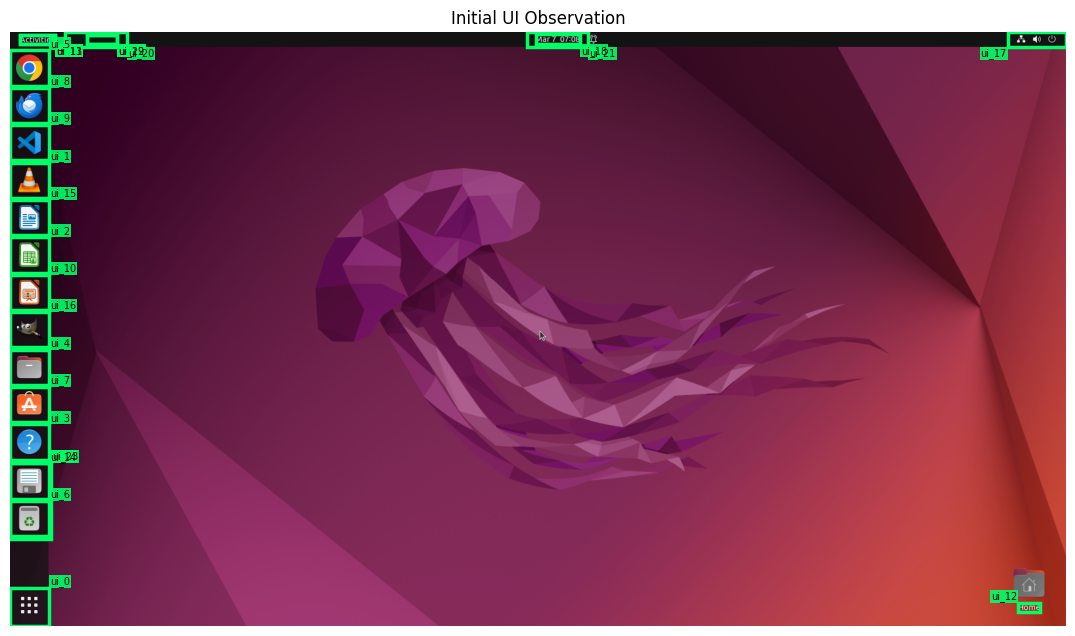

┌────┬───────┬────────┬────────────────────────────────┬──────────┬───────────────┬──────────────────────────────────────────────────────────────┬──────────┬────────────────┬────────────────┬────────────────────────────┐
│    │ id    │ kind   │ label                          │ source   │ a11y_role     │ states                                                       │    score │   vision_score │   fusion_score │ center_coords              │
├────┼───────┼────────┼────────────────────────────────┼──────────┼───────────────┼──────────────────────────────────────────────────────────────┼──────────┼────────────────┼────────────────┼────────────────────────────┤
│  0 │ ui_0  │ node   │ Show Applications              │ fusion   │ toggle-button │ ['enabled', 'focusable', 'sensitive', 'showing', 'visible']  │ 0.853157 │       0.331531 │       0.853157 │ {'x': 35.0, 'y': 1044.0}   │
├────┼───────┼────────┼────────────────────────────────┼──────────┼───────────────┼─────────────────────────────────

In [3]:
verbose = True

agent._last_task = task
agent.logger.info("Starting new task execution")
agent.logger.info("Task:\n%s", task)

# Reset environment and probe system
perception = agent.env.reset(task)
vm_info = agent.tools.os_inspector.probe()

# Episode bookkeeping
episode = Episode(
    episode_id=os.urandom(16).hex(),
    task=task,
    instruction=task.get("instruction"),
    status="STARTED",
    started_ts_ms=time.time_ns() // 1_000_000,
    os_name=vm_info["os"]["pretty_name"],
    desktop_env=vm_info.get("desktop_environment", "unknown"),
    display_server=vm_info.get("display_server", "unknown"),
)

agent.logger.info(
    "Episode started | episode_id=%s | task_id=%s",
    episode.episode_id,
    task.get("id"),
)

# --------------------------------------------------
# Initial observation (beliefs bootstrap)
# --------------------------------------------------

last_observation = agent.perception.process(perception)
agent.history_manager.update(last_observation, tags=["observation"])

if verbose:
    visualize_ui_elements(
        ui_dict=agent.history_manager.last_observation.ui_elements,
        screenshot=agent.history_manager.last_observation.screenshot,
        show_label=True,
        include_label_text=False,
        title="Initial UI Observation",
        text_color="#000000"

    )
    

#### Main loop

In [4]:
max_cycles = 1
verbose = False

for cycle in range(int(max_cycles)):
    agent.logger.info("=== Cycle %d / %d ===", cycle + 1, max_cycles)

    # ----------------------------
    # Planning (Desires)
    # ----------------------------

    action_chunk = agent.planner.propose_next_steps(
        task=task,
        history_manager=agent.history_manager,
        system_info=vm_info,
        memory = agent.memory_manager,
        tms = agent.tms
    )

    agent.history_manager.update(action_chunk, tags=["start_chunk"])

    agent.logger.info(
        "Planner produced chunk | macro_goal='%s' | decision=%s | steps=%d",
        action_chunk.macro_goal,
        action_chunk.decision,
        len(action_chunk.steps),
    )

    if action_chunk.decision in ("DONE", "FAIL"):
        agent.logger.info("Planner decided to %s. Ending loop.", action_chunk.decision)
        break

    # ----------------------------
    # Execution (Intentions)
    # ----------------------------

    for k, step in enumerate(action_chunk.steps):
        agent.history_manager.update(step, tags=["step"])

        agent.logger.debug(
            "Executing step %d | %s | type=%s | pause=%.2f",
            k,
            step.description,
            step.action_type,
            step.pause,
        )

        perception = agent.executor.execute_step(step)
        last_observation = agent.perception.process(perception)
        
        agent.history_manager.update(last_observation, tags=["observation", "observation_after_step"],)

        if verbose:
            visualize_ui_elements(
                ui_dict=agent.history_manager.last_observation.ui_elements,
                screenshot=agent.history_manager.last_observation.screenshot,
                show_label=True,
                include_label_text=False,
                title=f"Observation after step {k + 1}/{len(action_chunk.steps)}",
                text_color="#000000"

            )

    # ----------------------------
    # Evaluation (Judge)
    # ----------------------------

    agent.logger.info("Evaluating executed chunk")
    last_evaluation = agent.judge.evaluate_outcome(agent.history_manager)
    
    agent.history_manager.update({"chunk": action_chunk, "evaluation": last_evaluation}, tags=["end_chunk"])
    # Compact evaluation log
    agent._log_chunk_evaluation(agent.history_manager.last_chunk)

    # ----------------------------
    # Memory update (TRIM + TMS)
    # ----------------------------

    if agent.trim is not None and agent.tms is not None:
        agent.logger.info("Running TRIM")
        trim_out = agent.trim.run(
            task_instruction=task.get("instruction", ""),
            tms_nodes=agent.tms.nodes(),
            history_manager = agent.history_manager,
            current_observation=agent.history_manager.last_observation,
            chunk_digest=agent.history_manager.last_chunk_digest_for_tms(),
            cid=episode.episode_id,
        )
        agent.history_manager.update(trim_out, tags=["trim_info"])
        
        agent.logger.info("Updating TMS")
        agent.tms.apply_trim_output(
            trim_out,
            agent.history_manager.last_chunk,
            agent.history_manager.last_observation,
        )
    else:
        agent.logger.info("Skipping TRIM/TMS update because short-term memory is disabled.")

    agent.logger.info("Cycle %d completed\n", cycle + 1)

# --------------------------------------------------
# Final evaluation
# --------------------------------------------------

agent.logger.info("Agent finished execution. Evaluating final result.")
osworld_score = agent.env.evaluate()

episode.score = {
    "status": osworld_score["status"],
    "metric": osworld_score["result"]["metric"],
    "success": osworld_score["result"]["success"],
    "stats" : None
}

episode.finished_ts_ms = time.time_ns() // 1_000_000
episode.status = "DONE" if episode.score['success'] else "FAIL"

from agentz.memory.utils import append_metrics_csv

# Compute and attach metrics (history-based)
episode.score["stats"] = agent.history_manager.compute_metrics(episode)
append_metrics_csv(path = "../data/experiments.csv", episode = episode)

agent.memory_manager.ingest_end_of_episode(
    episode=episode,
    history_manager=agent.history_manager,
    tms=agent.tms
)

agent.logger.info("Final score: %s", episode.score)


=== Cycle 1 / 1 ===
UI prompt selection | raw=24 | kept=24 | selected=24 | max=80 | dropped=0 | critical=14/14 | active=1 | actionable=19
UI prompt selected_top=ui_1:push-button:VLC media player; ui_2:push-button:LibreOffice Calc; ui_3:push-button:Help; ui_4:push-button:Files; ui_5:push-button:Google Chrome; ui_0:toggle-button:Show Applications; ui_6:push-button:Trash; ui_7:push-button:Ubuntu Software; ui_8:push-button:Thunderbird Mail; ui_9:push-button:Visual Studio Code
Planner call | task_id=94d95f96-9699-4208-98ba-3c3119edf9c2 | last_chunk=No Previous Chunk | ui_elements=24 | tms_nodes=n/a
Planner UI digest | raw_ui=24 | digest_lines=24 | digest_chars=2449
Planner inputs | terminal_chars=24 | terminal_ui=False | last_failure=None
Planner inputs | terminal_transcript_present_but_no_terminal_ui | terminal_chars=24
Planner retry-meta | same_intent_retry=0 | wait_streak=0 | no_ui_change_streak=0 | last_chunk_ui_changed=true
Planner task_key input | instruction='I want to install Spotif

c:\Users\Luca\miniforge3\envs\thesis-env\lib\site-packages\transformers\generation\configuration_utils.py:638: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


Perception fusion filter | fused_before=103 | fused_after=82 | dedup_removed=21 | critical_controls_before=5 | critical_controls_after=5 | dedup_enabled=true
Perception obs_id=1 ui=78 vision=67 a11y=68 fused=82 terminal_chars=0 terminal_ui=False
Perception apps_top3=[('gnome-shell', 25), ('org.gnome.software', 21), ('gjs', 1)]
Perception windows_top3=[('software', 21), ('@!0,0;bdhf', 1)]
Executing step 1 | Wait for the Ubuntu Software application to fully load. | type=WAIT | pause=6.00


C:\Users\Luca\Desktop\GUI-agent\agent\agentz\perception\_ui_schema.py:573: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out = pd.concat(kept_groups, ignore_index=True)


STREAM b'IHDR' 16 13
STREAM b'IDAT' 41 65536


c:\Users\Luca\miniforge3\envs\thesis-env\lib\site-packages\transformers\generation\configuration_utils.py:638: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


Perception fusion filter | fused_before=103 | fused_after=82 | dedup_removed=21 | critical_controls_before=5 | critical_controls_after=5 | dedup_enabled=true
Perception obs_id=2 ui=78 vision=67 a11y=68 fused=82 terminal_chars=0 terminal_ui=False
Perception apps_top3=[('gnome-shell', 25), ('org.gnome.software', 21), ('gjs', 1)]
Perception windows_top3=[('software', 21), ('@!0,0;bdhf', 1)]
Evaluating executed chunk
Judge evidence | ui_before=24 | ui_after=78 | terminal_before_chars=0 | terminal_after_chars=0
Evaluating chunk. steps=2 images=2
temperature override applied | temp=0.0
model=gpt-4o temp=0.0 reasoning=None max_retries=3 images=2 detail=low
attempt=1 model=gpt-4o


C:\Users\Luca\Desktop\GUI-agent\agent\agentz\perception\_ui_schema.py:573: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out = pd.concat(kept_groups, ignore_index=True)


Interaction stored. model=gpt-4o prompt_tokens_est=6695 completion_tokens_est=211 success=True
Chunk end | success=True | failure_type=None | failing_step=None
Chunk result | success=True | failure_type=None | failing_step=None
  [Step 0] OK | Click the 'Ubuntu Software' button to open the application. | conf=1.00
  [Step 1] OK | Wait for the Ubuntu Software application to fully load. | conf=1.00
Skipping TRIM/TMS update because short-term memory is disabled.
Cycle 1 completed

Agent finished execution. Evaluating final result.
compute_task_key | instruction_norm='i want to install spotify on my current system could you please help me' | profile='ubuntu 22043 lts|gnome|x11' | raw='i want to install spotify on my current system could you please help me||ubuntu 22043 lts|gnome|x11' | key=2a8b4fdebfea0c3121b4e19ef9a8b13c6593d24d
EpisodicMemory task_key input | instruction='I want to install Spotify on my current system. Could you please help me?' | os_name='Ubuntu 22.04.3 LTS' | desktop_e

In [ ]:
from typing import Dict, Any, List, Optional


def visualize_episode(*, episode, history, tms) -> Dict[str, str]:
    """
    Build a human-readable visualization of:
    - Episode metadata
    - Execution trace (chunks + steps + failures)
    - TMS structure (tree + detailed per-node blocks + table)

    Returns a dict of named text artifacts.
    """

    artifacts: Dict[str, str] = {}

    # ---------------------------
    # Helpers
    # ---------------------------

    def _clip(s: Optional[str], n: int = 110) -> str:
        if not s:
            return ""
        s = " ".join(str(s).split())
        return s if len(s) <= n else s[: n - 1] + "…"

    def _fmt_bool(b: Optional[bool]) -> str:
        if b is True:
            return "T"
        if b is False:
            return "F"
        return "-"

    def _fmt_status(x) -> str:
        # Supports enums with .name or plain strings
        return getattr(x, "name", str(x))

    def _fmt_anchor(a) -> str:
        # Expected anchor fields: label, role, qx, qy
        label = getattr(a, "label", "") or ""
        role = getattr(a, "role", "") or ""
        qx = getattr(a, "qx", None)
        qy = getattr(a, "qy", None)
        lr = f"{label}|{role}".strip("|")
        if qx is None or qy is None:
            return lr or "<anchor>"
        return f"{lr}|q({qx},{qy})"

    def _node_mark(node) -> str:
        # Prefer node.last_success if present
        success = getattr(node, "last_success", None)
        if success is True:
            return "✔"
        if success is False:
            return "✖"
        return "·"

    # ============================================================
    # EPISODE HEADER
    # ============================================================

    header_lines: List[str] = []
    header_lines.append("EPISODE SUMMARY")
    header_lines.append("=" * 100)
    header_lines.append(f"Episode ID     : {episode.episode_id}")
    header_lines.append(f"Task           : {_clip(episode.instruction, 160)}")
    header_lines.append(f"Status         : {episode.status}")
    header_lines.append(f"OS             : {episode.os_name}")
    header_lines.append(f"Desktop        : {episode.desktop_env}")
    header_lines.append(f"Display Server : {episode.display_server}")

    if episode.finished_ts_ms:
        duration = episode.finished_ts_ms - episode.started_ts_ms
        header_lines.append(f"Duration (ms)  : {duration}")

    artifacts["episode_header"] = "\n".join(header_lines)

    # ============================================================
    # EXECUTION TRACE (CHUNKS + STEPS)
    # ============================================================

    trace_lines: List[str] = []
    trace_lines.append("EXECUTION TRACE")
    trace_lines.append("=" * 100)

    if not getattr(history, "chunks_history", None):
        trace_lines.append("(no chunks executed)")
    else:
        for ci, chunk in enumerate(history.chunks_history, start=1):
            trace_lines.append("")
            trace_lines.append(f"CHUNK {ci}")
            trace_lines.append("-" * 100)
            trace_lines.append(f"Macro-goal      : {_clip(chunk.macro_goal, 140)}")
            trace_lines.append(f"Decision        : {chunk.decision}")
            trace_lines.append(f"Overall success : {_fmt_bool(chunk.overall_success)}")
            trace_lines.append(f"Failure type    : {chunk.failure_type}")
            trace_lines.append(f"Failing step    : {chunk.failing_step_index}")
            trace_lines.append(f"Post state      : {_clip(chunk.post_chunk_state, 180)}")
            if getattr(chunk, "planner_guidance", None):
                trace_lines.append(f"Planner guidance: {_clip(chunk.planner_guidance, 180)}")

            trace_lines.append("")
            trace_lines.append("Steps:")
            for step, eval_ in zip(chunk.steps, chunk.steps_eval):
                mark = "✔" if eval_.success else "✖"
                trace_lines.append(f"  [{mark}] Step {step.index}: {_clip(step.description, 140)}")
                trace_lines.append(f"       expected : {_clip(step.expected_outcome, 160)}")
                trace_lines.append(f"       evidence : {_clip(eval_.evidence, 180)}")
                if not eval_.success:
                    if getattr(eval_, "failure_reason", None):
                        trace_lines.append(f"       reason   : {_clip(eval_.failure_reason, 160)}")
                    if getattr(eval_, "fix_suggestion", None):
                        trace_lines.append(f"       fix      : {_clip(eval_.fix_suggestion, 160)}")

    artifacts["execution_trace"] = "\n".join(trace_lines)

    # ============================================================
    # TMS TREE VIEW (NO GRAPHVIZ)
    # ============================================================

    def _build_adjacency():
        children: Dict[str, List[str]] = {}
        parents: set[str] = set()
        for e in tms.edges():
            children.setdefault(e.parent_id, []).append(e.child_id)
            parents.add(e.child_id)

        # Keep deterministic order
        for k in children:
            children[k] = sorted(children[k])

        roots = sorted([n.node_id for n in tms.nodes() if n.node_id not in parents])
        return roots, children

    def _render_node(node_id: str, prefix: str = "", is_last: bool = True) -> List[str]:
        node = tms.get_node(node_id)
        if not node:
            return []

        branch = "└─ " if is_last else "├─ "
        status = _fmt_status(node.status)
        lines = [f"{prefix}{branch}{_node_mark(node)} {node.title} [{status}] ({node.node_id})"]

        # Keep the tree compact: only show a clipped value and quick metadata
        if getattr(node, "value", None):
            lines.append(f"{prefix}   value: {_clip(node.value, 140)}")

        if getattr(node, "last_outcome", None):
            lines.append(f"{prefix}   last_outcome: {_clip(node.last_outcome, 140)}")

        if getattr(node, "last_guidance", None):
            lines.append(f"{prefix}   last_guidance: {_clip(node.last_guidance, 140)}")

        revs = getattr(node, "revisions", None) or []
        anchors = getattr(node, "anchors", None) or []
        upd = getattr(node, "last_updated_step", None)
        lines.append(f"{prefix}   meta: rev={len(revs)} anc={len(anchors)} last_step={upd}")

        kids = children_map.get(node_id, [])
        for i, child in enumerate(kids):
            last = i == len(kids) - 1
            ext = "   " if is_last else "│  "
            lines.extend(_render_node(child, prefix + ext, last))

        return lines

    tree_lines: List[str] = []
    tree_lines.append("TASK MEMORY STRUCTURE (TREE)")
    tree_lines.append("=" * 100)

    roots, children_map = _build_adjacency()
    if not roots:
        tree_lines.append("(empty TMS)")
    else:
        for r in roots:
            tree_lines.extend(_render_node(r))
            tree_lines.append("")

    artifacts["tms_tree"] = "\n".join(tree_lines).rstrip()

    # ============================================================
    # TMS NODE DETAILS (PRINTABLE BLOCKS)
    # ============================================================

    details_lines: List[str] = []
    details_lines.append("TASK MEMORY STRUCTURE (NODE DETAILS)")
    details_lines.append("=" * 100)

    # Sort nodes by title for readability
    nodes_sorted = sorted(list(tms.nodes()), key=lambda n: (getattr(n, "title", ""), getattr(n, "node_id", "")))
    for n in nodes_sorted:
        status = _fmt_status(n.status)
        details_lines.append("")
        details_lines.append(f"[{n.node_id}] [{status}]")
        details_lines.append(f"title={n.title}")
        details_lines.append(f"value={_clip(getattr(n, 'value', ''), 220)}")

        revs = getattr(n, "revisions", None) or []
        anchors = getattr(n, "anchors", None) or []
        details_lines.append(f"rev={len(revs)} anc={len(anchors)} last_step={getattr(n, 'last_updated_step', None)}")

        # Revisions: show a compact timeline (rev_id:summary)
        if revs:
            rev_items = []
            for r in revs:
                rid = getattr(r, "rev_id", "?")
                summ = getattr(r, "summary", None) or ""
                if not summ:
                    # Fallback: tag based on value presence
                    summ = "update"
                rev_items.append(f"r{rid}:{summ}")
            details_lines.append(f"revisions=[{', '.join(rev_items[:12])}{'…' if len(rev_items) > 12 else ''}]")
        else:
            details_lines.append("revisions=[]")

        # Anchors: show up to N anchors as "label|role|q(x,y)"
        if anchors:
            anc_items = [_fmt_anchor(a) for a in anchors]
            details_lines.append(f"anchors=[{', '.join(anc_items[:10])}{'…' if len(anc_items) > 10 else ''}]")
        else:
            details_lines.append("anchors=[]")

        # Optional judge-derived metadata if present
        if getattr(n, "last_success", None) is not None:
            details_lines.append(f"last_success={getattr(n, 'last_success')}")
        if getattr(n, "last_outcome", None):
            details_lines.append(f"last_outcome={_clip(getattr(n, 'last_outcome'), 220)}")
        if getattr(n, "last_guidance", None):
            details_lines.append(f"last_guidance={_clip(getattr(n, 'last_guidance'), 220)}")

    artifacts["tms_node_details"] = "\n".join(details_lines).rstrip()

    # ============================================================
    # TMS TABLE VIEW (COMPACT)
    # ============================================================

    table_lines: List[str] = []
    table_lines.append("TASK MEMORY STRUCTURE (TABLE)")
    table_lines.append("=" * 100)
    table_lines.append(
        f"{'ID':<22} {'STATUS':<10} {'REV':>3} {'ANC':>3} {'SUC':>3} {'LAST':>5}  TITLE / VALUE"
    )
    table_lines.append("-" * 100)

    for n in nodes_sorted:
        nid = n.node_id
        status = _fmt_status(n.status)
        revs = getattr(n, "revisions", None) or []
        anchors = getattr(n, "anchors", None) or []
        suc = getattr(n, "last_success", None)
        last_step = getattr(n, "last_updated_step", None)
        title = _clip(getattr(n, "title", ""), 44)
        value = _clip(getattr(n, "value", ""), 54)
        table_lines.append(
            f"{nid:<22} {status:<10} {len(revs):>3} {len(anchors):>3} {_fmt_bool(suc):>3} "
            f"{str(last_step):>5}  {title} | {value}"
        )

    artifacts["tms_table"] = "\n".join(table_lines)

    return artifacts


# Example usage
artifacts = visualize_episode(
    episode=episode,
    history=agent.history_manager,
    tms=agent.tms,
)

print(artifacts["episode_header"])
print()
print(artifacts["execution_trace"])
print()
print(artifacts["tms_tree"])
print()
print(artifacts["tms_node_details"])
print()
print(artifacts["tms_table"])